<a href="https://colab.research.google.com/github/RajeshRanaGiet/AML-LAB/blob/main/Experiment%203/exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Intercept: 0.003701320933595653
Coefficients: [0.24972369 0.25041241 0.249574   0.24999223]

y=0.0037 + 0.2497*SEM 1 + 0.2504*SEM 2 + 0.2496*SEM 3 + 0.2500*SEM 4

Mean Squared Error: 8.532099100609133e-06
Mean Absolute Error: 0.0025622780796985874
Root Mean square Error:  0.0029209757103764375
R-squared: 0.9999989080650641


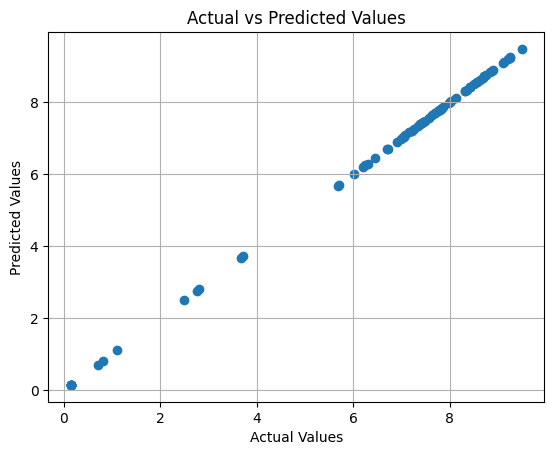

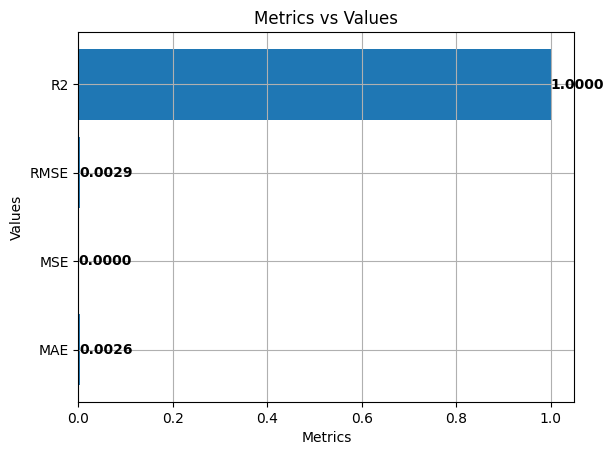

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

data = pd.read_csv('studentGradeDataSet.csv')

x = data.drop('SEM 5', axis=1)
y = data['SEM 5']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model = LinearRegression()
model.fit(x_train, y_train)

pred_model = model.predict(x_test)

mse = mean_squared_error(y_test, pred_model)
mae = mean_absolute_error(y_test, pred_model)
rmse  = np.sqrt(mse)
r2 = r2_score(y_test, pred_model)

intercept = model.intercept_
coefficients = model.coef_
eqn = f"y={intercept:.4f} + " + " + ".join([f"{coef:.4f}*{col}" for coef, col in zip(coefficients, x.columns)])

print("Intercept:", intercept)
print("Coefficients:", coefficients)
print("\n"+eqn)
print("\nMean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean square Error: ", rmse)
print("R-squared:", r2)

print("Enter the data for prediction :- ")
s1 = int(input("Enter the 1st Semester marks: "))
s2 = int(input("Enter the 2nd Semester marks: "))
s3 = int(input("Enter the 3rd Semester marks: "))
s4 = int(input("Enter the 4th Semester marks: "))
test = pd.DataFrame({"SEM 1" : [s1],
                     "SEM 2" : [s2],
                     "SEM 3" : [s3],
                     "SEM 4" : [s4]})

pred_val = model.predict(test)
print("The predicted 5th sem mark is : ", pred_val[0])

plt.scatter(y_test, pred_model)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.grid(True)
plt.show()

metrics = ["MAE", "MSE", "RMSE", "R2"]
values = [mae, mse, rmse, r2]

bars = plt.barh(metrics, values)
for bar in bars:
  width = bar.get_width()
  plt.annotate(f"{width:.4f}", xy=(width, bar.get_y() + bar.get_height() / 2),ha="left", va="center", fontweight="bold")
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.title("Metrics vs Values")
plt.grid(True)
plt.show()



### Correlation Heatmap

Let's visualize the correlation matrix of all features, including the target variable 'SEM 5', to understand the relationships between them.

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Student Grades')
plt.show()

### Feature Distribution (Box Plots)

Now, let's look at the distribution of each semester's marks using box plots to identify any outliers or skewness.

In [ ]:
fig, axes = plt.subplots(1, len(x.columns), figsize=(15, 5))
for i, col in enumerate(x.columns):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('')
plt.tight_layout()
plt.show()

### Simple Linear Regression for Each Feature

Let's perform simple linear regression for each independent semester (SEM 1, SEM 2, SEM 3, SEM 4) against the dependent variable (SEM 5) to see their individual predictive power.

In [ ]:
for feature in x.columns:
    print(f"\n--- Simple Linear Regression for {feature} ---")
    X_simple = data[[feature]] # Use double brackets to keep it as a DataFrame
    y_simple = data['SEM 5']

    # Split the data into training and testing sets for simple linear regression
    X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

    model_simple = LinearRegression()
    model_simple.fit(X_train_simple, y_train_simple)

    predictions_simple = model_simple.predict(X_test_simple)

    mse_simple = mean_squared_error(y_test_simple, predictions_simple)
    mae_simple = mean_absolute_error(y_test_simple, predictions_simple)
    rmse_simple = np.sqrt(mse_simple)
    r2_simple = r2_score(y_test_simple, predictions_simple)

    intercept_simple = model_simple.intercept_
    coefficient_simple = model_simple.coef_[0]

    print(f"Equation: y = {intercept_simple:.4f} + {coefficient_simple:.4f}*{feature}")
    print(f"Mean Squared Error: {mse_simple:.4f}")
    print(f"Mean Absolute Error: {mae_simple:.4f}")
    print(f"Root Mean Squared Error: {rmse_simple:.4f}")
    print(f"R-squared: {r2_simple:.4f}")

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.scatter(X_test_simple, y_test_simple, color='blue', label='Actual Values')
    plt.plot(X_test_simple, predictions_simple, color='red', linewidth=2, label='Regression Line')
    plt.xlabel(feature)
    plt.ylabel('SEM 5')
    plt.title(f'Simple Linear Regression: {feature} vs SEM 5')
    plt.legend()
    plt.grid(True)
    plt.show()